In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from figures_setup import *
from utils import set_color_code

## Read data: biobank tissue epithelial dataset

In [14]:
# Read input data
file = os.path.join(dir_data, "biobank_tissue_epi.h5ad")
adata = sc.read_h5ad(file)

## Stem cell composition

In [15]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata)

In [16]:
adata.obs["donor_id"].value_counts() # Fig S1N

donor_id
HD4272    296
HD4362    228
HD4309     72
HD4254     57
HD4249     50
HD4246     45
HD4181     20
HD4241     17
Name: count, dtype: int64

In [17]:
# Set color code and plot barplot
from utils_biobank_tissue import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

/tmp/ipykernel_339562/913482307.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['SC_status']


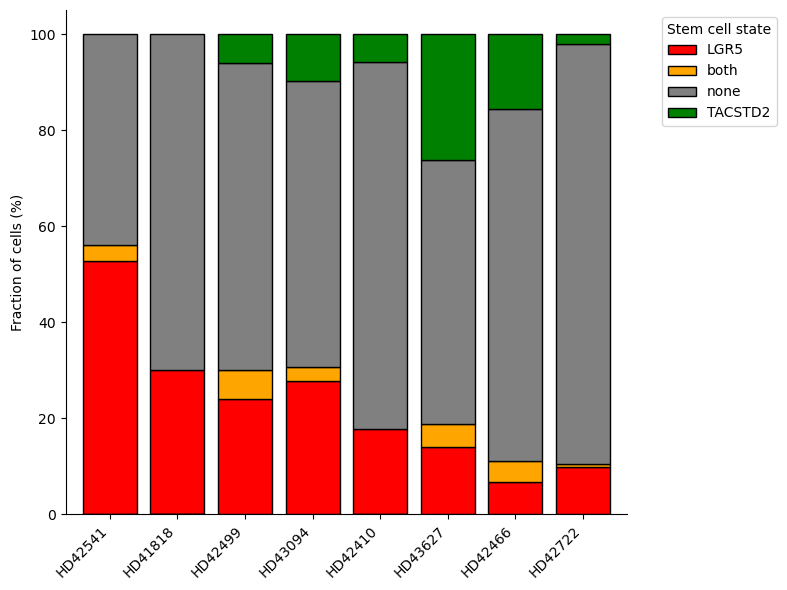

In [18]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on LGR5 levels in descending order
df = df.sort_values(by='LGR5', ascending=False)
# Sort DataFrame based on predefined donor order
df = df.reindex(order_donor_id)

# Barplot mimicking Fig S1N
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(8, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()